# Import libraries and polygons

In [1]:
import os

os.environ["PROJ_LIB"] = "/home/abernard/miniconda3/envs/geo_clean/share/proj"
os.environ["PROJ_DATA"] = "/home/abernard/miniconda3/envs/geo_clean/share/proj"
os.environ["GDAL_DATA"] = "/home/abernard/miniconda3/envs/geo_clean/share/gdal"

In [2]:
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import rioxarray as rio
import pandas as pd


In [3]:
from pyproj import CRS

print(CRS.from_epsg(2154))

EPSG:2154


In [4]:
gdf = gpd.read_file("../data/RNN_limite_poly_l93.shp")

gdf = gdf.set_crs("EPSG:2154")

gdf = gdf.to_crs("EPSG:4326")


gdf2 = gpd.read_file("../data/limite_RI_wgs84.shp")
gdf2 = gdf2.set_crs("EPSG:4326")

/home/abernard/miniconda3/envs/geo_clean/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection.
  return ogr_read(
/home/abernard/miniconda3/envs/geo_clean/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: Geometry of polygon of fid 0 cannot be translated to Simple Geometry. All polygons will be contained in a multipolygon.
  return ogr_read(


# unpack netCDF file to make understandable data

In [5]:
#### NET CDF ######

ds = xr.open_dataset("../data/MODIS_IMG/MOD09GQ.061_250m_aid0001.nc")

In [6]:
red = ds["sur_refl_b01_1"]
nir = ds["sur_refl_b02_1"]

ndvi = (nir - red) / (nir + red)
ds["NDVI"] = ndvi
ds["NDVI"].attrs = {
    "long_name": "Normalized Difference Vegetation Index"
}

In [7]:
red = ds["sur_refl_b01_1"]

nir = ds["sur_refl_b02_1"]

# Masquer valeurs invalides
red = red.where(
    (red >= -100)
    &
    (red <= 16000)
)

nir = nir.where(
    (nir >= -100)
    &
    (nir <= 16000)
)

# Conversion réflectance
red = red / 10000.0
nir = nir / 10000.0

# NDVI
ndvi = (nir - red) / (nir + red)

# Filtrer valeurs physiques impossibles
ndvi = ndvi.where(
    (ndvi >= -1)
    &
    (ndvi <= 1)
)

ds["NDVI"] = ndvi
ds["NDVI"].attrs = {
    "long_name": "Normalized Difference Vegetation Index"
}

In [8]:
ndvi_day = ds["NDVI"].sel(time="2026-05-18")

# 2026-05-17 elle ça va
# 2026-05-18 là ça va pas

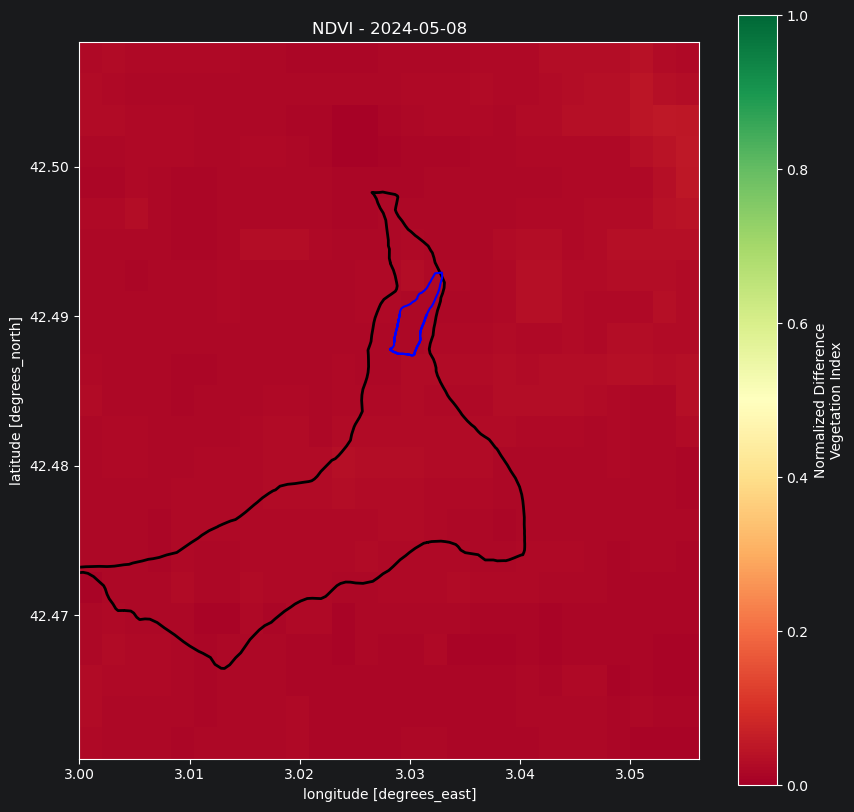

In [9]:
fig, ax= plt.subplots(figsize=(10, 10))

ndvi_day.plot(
    vmin=0,
    vmax=1,
    cmap="RdYlGn"
)

gdf.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

gdf2.boundary.plot(
    ax=ax,
    color="blue"
)

plt.title("NDVI - 2024-05-08")

plt.show()

# Extract the dataset from MODIS images

In [10]:
# filter clouds and other atmospheric stuff

ds = ds.rio.write_crs("EPSG:4326")
qc = ds["QC_250m_1"].astype("uint16")
qc = qc.rio.write_crs("EPSG:4326")

/home/abernard/miniconda3/envs/geo_clean/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:268: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [11]:
modland = qc & 0b11
b1_quality = (qc >> 4) & 0b1111
b2_quality = (qc >> 8) & 0b1111
atm_corr = (qc >> 12) & 0b1
adj_corr = (qc >> 13) & 0b1
diff_orbit = (qc >> 14) & 0b1

good = (
    (modland == 0)
    &
    (b1_quality == 0)
    &
    (b2_quality == 0)
    &
    (atm_corr == 1)
)# on ne garde que les meilleurs pixels

ds_clean = ds.where(good)


In [12]:
clipped_ndvi = ds_clean["NDVI"].rio.clip(
    gdf.geometry,
    gdf.crs,
    drop=True
)

clipped_good = good.rio.clip(
    gdf.geometry,
    gdf.crs,
    drop=True
)

In [13]:
dates_valides = []
moyennes_ndvi = []
median_ndvi = []
ratios_good = []

for t in range(clipped_ndvi.sizes["time"]):

    ndvi_t = clipped_ndvi.isel(time=t)

    good_t = clipped_good.isel(time=t)

    # Pourcentage de bons pixels
    ratio_good = good_t.mean().item()

    # Garder seulement si > 95%
    if ratio_good > 0.95:

        # Moyenne NDVI uniquement sur les bons pixels
        mean_ndvi = ndvi_t.where(good_t).mean().item()
        med_ndvi = ndvi_t.where(good_t).median().item()

        dates_valides.append(
            pd.to_datetime(str(ndvi_t.time.values))
        )

        moyennes_ndvi.append(mean_ndvi)
        median_ndvi.append(med_ndvi)

        ratios_good.append(ratio_good)

In [14]:

df = pd.DataFrame({
    "date": dates_valides,
    "mean_ndvi": moyennes_ndvi,
    "median_ndvi": median_ndvi,
    "ratio_good": ratios_good
})

# Trier par date
df = df.sort_values("date")
df_clean = df[df["median_ndvi"] > 0.25]


# create a dynamic threshold with the 8 days product

In [15]:
ds_q1 = xr.open_dataset("../data/MODIS_IMG/MOD09Q1.061_250m_aid0001.nc")
ds_q1 = ds_q1.rio.write_crs("EPSG:4326")

In [16]:
qc_q1 = ds_q1["sur_refl_qc_250m"].astype("uint16")
qc_q1 = qc_q1.rio.write_crs("EPSG:4326")


In [17]:

modland_q1 = qc_q1 & 0b11

good_q1 = (
        modland_q1 == 0
)  # on ne garde que les meilleurs pixels

In [18]:
ds_q1_clean = ds_q1.where(good_q1)

In [19]:

red_q1 = ds_q1_clean["sur_refl_b01"]
nir_q1 = ds_q1_clean["sur_refl_b02"]

ndvi_q1 = (nir_q1 - red_q1) / (nir_q1 + red_q1)
ds_q1["NDVI"] = ndvi_q1
ds_q1["NDVI"].attrs = {
    "long_name": "Normalized Difference Vegetation Index"
}

In [20]:
clipped_ndvi = ds_q1["NDVI"].rio.clip(
    gdf.geometry,
    gdf.crs,
    drop=True
)

clipped_good = good_q1.rio.clip(
    gdf.geometry,
    gdf.crs,
    drop=True
)

In [21]:
dates_valides = []
moyennes_ndvi = []
median_ndvi = []
ratios_good = []

for t in range(clipped_ndvi.sizes["time"]):

    ndvi_t = clipped_ndvi.isel(time=t)

    good_t = clipped_good.isel(time=t)

    # Pourcentage de bons pixels
    ratio_good = good_t.mean().item()

    # Garder seulement si > 95%
    if ratio_good > 0.95:

        # Moyenne NDVI uniquement sur les bons pixels
        mean_ndvi = ndvi_t.where(good_t).mean().item()
        med_ndvi = ndvi_t.where(good_t).median().item()

        dates_valides.append(
            pd.to_datetime(str(ndvi_t.time.values))
        )

        moyennes_ndvi.append(mean_ndvi)
        median_ndvi.append(med_ndvi)

        ratios_good.append(ratio_good)

In [22]:
df_q1 = pd.DataFrame({
    "date": dates_valides,
    "mean_ndvi_q1": moyennes_ndvi,
    "median_ndvi_q1": median_ndvi,
    "ratio_good_q1": ratios_good
})

# Trier par date
df_q1 = df_q1.sort_values("date")

print(df_q1)

          date  mean_ndvi_q1  median_ndvi_q1  ratio_good_q1
0   2023-12-27      0.632315        0.643887            1.0
1   2024-01-01      0.576060        0.602291            1.0
2   2024-01-09      0.638097        0.648283            1.0
3   2024-01-17      0.602244        0.615987            1.0
4   2024-01-25      0.567216        0.578066            1.0
..         ...           ...             ...            ...
106 2026-04-15      0.715093        0.724394            1.0
107 2026-04-23      0.805871        0.827128            1.0
108 2026-05-01      0.476863        0.492137            1.0
109 2026-05-09      0.566536        0.639186            1.0
110 2026-05-17      0.828423        0.850563            1.0

[111 rows x 4 columns]


<Axes: xlabel='date'>

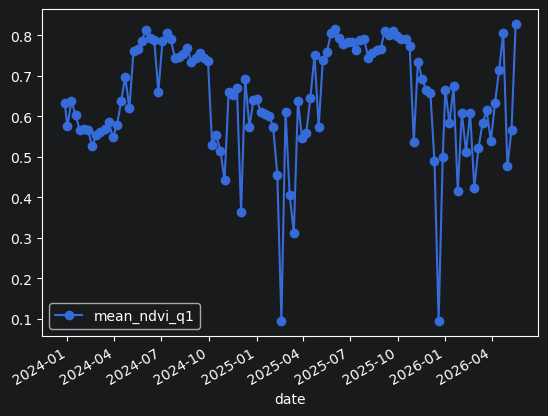

In [23]:
df_q1.plot(
    x="date",
    y="mean_ndvi_q1",
    marker="o"
)

In [24]:
df_q1 = df_q1.set_index("date")

df_q1_daily = (
    df_q1
    .resample("D")
    .interpolate()
)

In [25]:
margin = 0.1
df_q1_daily["lower"] = (
    df_q1_daily["mean_ndvi_q1"]
    - margin
)

df_q1_daily["upper"] = (
    df_q1_daily["mean_ndvi_q1"]
    + margin
)

In [26]:
df_daily = df_clean.merge(
    df_q1_daily.reset_index(),
    on="date",
    how="left"
)

In [27]:
df_daily["inside_corridor"] = (
    (
        df_daily["mean_ndvi"]
        >= df_daily["lower"]
    )
    &
    (
        df_daily["mean_ndvi"]
        <= df_daily["upper"]
    )
)

In [28]:
df_clean = df_daily[
    df_daily["inside_corridor"]
]

In [ ]:
df_clean

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))

#ax.set_xlim(
#    pd.Timestamp("2024-03-01"),
#    pd.Timestamp("2024-06-30")
#)

# corridor
ax.fill_between(
    df_q1_daily.index,
    df_q1_daily["lower"],
    df_q1_daily["upper"],
    alpha=0.3,
    label="Couloir MOD09Q1"
)

# référence Q1
ax.plot(
    df_q1_daily.index,
    df_q1_daily["mean_ndvi_q1"],
    linewidth=2,
    label="MOD09Q1"
)

# journalier
ax.scatter(
    df_daily["date"],
    df_daily["mean_ndvi"],
    s=10,
    alpha=0.5,
    label="MOD09GQ"
)

# points gardés
ax.scatter(
    df_clean["date"],
    df_clean["mean_ndvi"],
    s=15,
    label="Points retenus"
)

ax.set_ylim(0,1)

ax.legend()

ax.grid()

plt.show()

# Lets try it with MOD13 product

In [15]:
ds_q1 = xr.open_dataset("../data/MODIS_IMG/MOD13Q1.061_250m_aid0001.nc")
ds_q1 = ds_q1.rio.write_crs("EPSG:4326")

In [16]:
clipped_ndvi = ds_q1["_250m_16_days_NDVI"].rio.clip(
    gdf.geometry,
    gdf.crs,
    drop=True
)

In [17]:
dates_ndvi = []
moyennes_ndvi = []


for t in range(clipped_ndvi.sizes["time"]):

    ndvi_t = clipped_ndvi.isel(time=t)


    mean_ndvi = ndvi_t.where(good_t).mean().item()

    dates_ndvi.append(
        pd.to_datetime(str(ndvi_t.time.values))
    )

    moyennes_ndvi.append(mean_ndvi)

In [18]:
df_q1 = pd.DataFrame({
    "date": dates_ndvi,
    "mean_ndvi_q1": moyennes_ndvi
})

# Trier par date
df_q1 = df_q1.sort_values("date")

In [19]:
df_q1 = df_q1.set_index("date")

df_q1_daily = (
    df_q1
    .resample("D")
    .interpolate()
)

In [20]:
margin = 0.1
df_q1_daily["lower"] = (
    df_q1_daily["mean_ndvi_q1"]
    - margin
)

df_q1_daily["upper"] = (
    df_q1_daily["mean_ndvi_q1"]
    + margin
)

In [21]:
df_daily = df_clean.merge(
    df_q1_daily.reset_index(),
    on="date",
    how="left"
)


In [22]:
df_daily["inside_corridor"] = (
        (
                df_daily["mean_ndvi"]
                >= df_daily["lower"]
        )
        &
        (
                df_daily["mean_ndvi"]
                <= df_daily["upper"]
        )
)

df_clean = df_daily[
    df_daily["inside_corridor"]
]

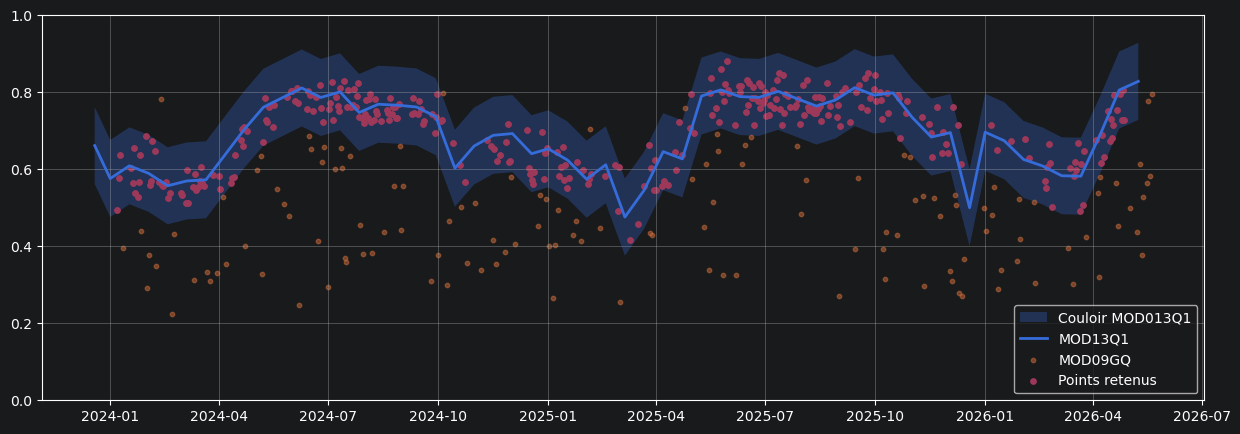

In [23]:
fig, ax = plt.subplots(figsize=(15,5))

#ax.set_xlim(
#    pd.Timestamp("2024-03-01"),
#    pd.Timestamp("2024-06-30")
#)

# corridor
ax.fill_between(
    df_q1_daily.index,
    df_q1_daily["lower"],
    df_q1_daily["upper"],
    alpha=0.3,
    label="Couloir MOD013Q1"
)

# référence Q1
ax.plot(
    df_q1_daily.index,
    df_q1_daily["mean_ndvi_q1"],
    linewidth=2,
    label="MOD13Q1"
)

# journalier
ax.scatter(
    df_daily["date"],
    df_daily["mean_ndvi"],
    s=10,
    alpha=0.5,
    label="MOD09GQ"
)

# points gardés
ax.scatter(
    df_clean["date"],
    df_clean["mean_ndvi"],
    s=15,
    label="Points retenus"
)

ax.set_ylim(0,1)

ax.legend()

ax.grid()

plt.show()

# export the full dataset

In [ ]:
print(df_clean)

In [ ]:
df_clean.to_csv("output/NDVI_modis.csv", index=False, float_format="%.3f", columns=["date", "mean_ndvi"])